In [1]:
!pip install transformers peft trl accelerate bitsandbytes datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.6 MB/s eta 0:00:00


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
print("TinyLlama loaded!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

TinyLlama loaded!


In [2]:
messages = [{"role": "user", "content": "INtroduce yourself"}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(text, return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0]))


<s> <|user|>
INtroduce yourself</s> 
<|assistant|>
I am a software engineer with over 5 years of experience in developing web applications using various technologies such as Java, JavaScript, and React. I have worked on projects ranging from small startups to large enterprises, and I have a strong background in designing and implementing scalable solutions.

in my current role as a software engineer at [company name], I am responsible for developing and maintaining web applications using the latest technologies and best practices. I work closely with the product team to understand their requirements and design solutions that meet their needs.

one of my recent projects was working on a web application for a healthcare provider. The application was designed to provide a user-friendly platform for patients to manage their healthcare records, schedule appointments, and receive notifications. I was responsible for designing the user interface, implementing the backend API, and developing t

In [2]:
from google.colab import files
uploaded = files.upload()  # Upload train.jsonl and val.jsonl

import json

# Check uploaded files
with open("train.jsonl") as f:
    train_samples = [json.loads(line) for line in f]

with open("val.jsonl") as f:
    val_samples = [json.loads(line) for line in f]

print(f"Train samples: {len(train_samples)}")
print(f"Val samples: {len(val_samples)}")
print(f"\nSample data:")
print(json.dumps(train_samples[0], indent=2))


Saving val.jsonl to val.jsonl
Saving train.jsonl to train.jsonl
Train samples: 1600
Val samples: 400

Sample data:
{
  "instruction": "Extract the function name and parameters from the code.",
  "input": "def linear_search(data, target):\n    for i in range(len(data)):\n        if data[i] == target:\n            return i\n    return -1",
  "output": "{\"function_name\": \"linear_search\", \"parameters\": [\"data\", \"target\"]}"
}


In [4]:
!pip install tiktoken


Total samples analyzed: 1600
Avg tokens: 75.27
Max: 155, Min: 25


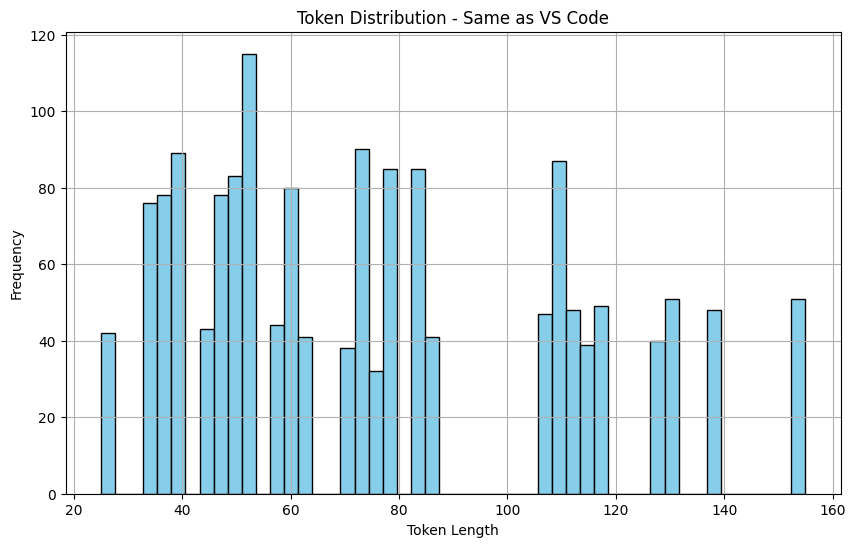

In [5]:
import tiktoken
import matplotlib.pyplot as plt

# Use  tokenizer (cl100k_base)
encoding = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    if not text:
        return 0
    return len(encoding.encode(text))

# Analyze tokens
lengths = []
for sample in train_samples:  # Check all samples
    instruction = sample.get('instruction', '')
    input_text = sample.get('input', '')
    output = sample.get('output', '')

    total = count_tokens(instruction) + count_tokens(input_text) + count_tokens(output)
    lengths.append(total)

print(f"Total samples analyzed: {len(lengths)}")
print(f"Avg tokens: {sum(lengths)/len(lengths):.2f}")
print(f"Max: {max(lengths)}, Min: {min(lengths)}")

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.title('Token Distribution - Same as VS Code')
plt.grid(True)
plt.show()
